# Paper plots
Questo notebook genera i plot richiesti dal paper usando i CSV in `../results/`.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

RECORDS = '../results/records.csv'
LRA = '../results/lra_records.csv'
EFF = '../results/efficiency.csv'


In [40]:
# Utils

def load_records():
    df = pd.read_csv(RECORDS, index_col=0)
    df.index.name = 'dataset'
    df['group'] = df.index.str.split('/').str[0]
    df['short'] = df.index.str.split('/').str[1]
    return df


def to_numeric(df):
    return df.apply(pd.to_numeric, errors='coerce')


def kmer_metric_cols(df, metric, include_multi=True):
    cols = [c for c in df.columns if c.startswith('kmer_k') and c.endswith('_' + metric)]
    if include_multi:
        cols += [c for c in df.columns if c.startswith('kmer_multi') and c.endswith('_' + metric)]
    return cols


def fm_metric_cols(df, metric):
    return [c for c in df.columns if c.startswith('fm_') and c.endswith('_' + metric)]


def best_kmer(df, metric, include_multi=True):
    cols = kmer_metric_cols(df, metric, include_multi=include_multi)
    out = df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
    out.name = f'best_kmer_{metric}'
    return out


def best_fm(df, metric):
    cols = fm_metric_cols(df, metric)
    out = df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1)
    out.name = f'best_fm_{metric}'
    return out


def dataset_palette(df):
    groups = sorted(df['group'].dropna().unique())
    cmap = plt.colormaps['tab20']
    return {g: cmap(i) for i, g in enumerate(groups)}


## 1) Per ogni FM: best k-mer (y) vs performance FM (x)


/tmp/ipykernel_2185422/1015451025.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['group'] = df.index.str.split('/').str[0]
/tmp/ipykernel_2185422/1015451025.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['short'] = df.index.str.split('/').str[1]


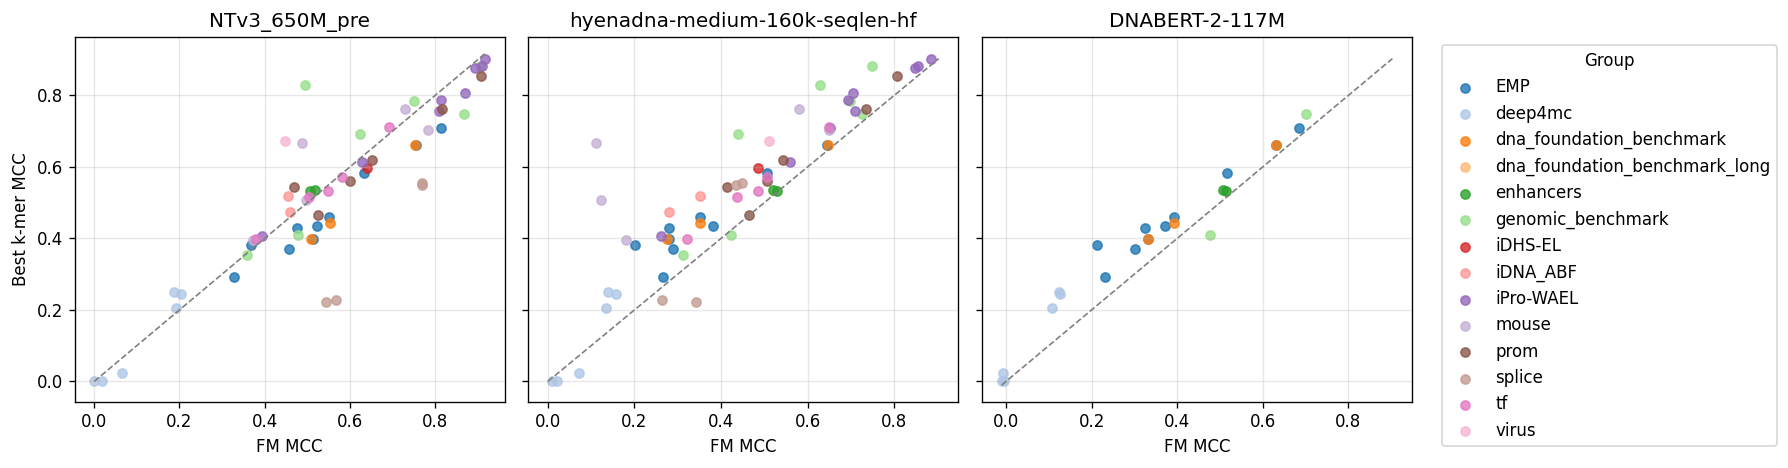

In [41]:
metric = 'MCC'  # cambia in AUROC/F1/Accuracy se serve

df = load_records()
cols_fm = fm_metric_cols(df, metric)
palette = dataset_palette(df)

best_k = best_kmer(df, metric)

n = len(cols_fm)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, cols_fm):
    x = pd.to_numeric(df[col], errors='coerce')
    y = best_k
    for g, sub in df.groupby('group'):
        ax.scatter(x.loc[sub.index], y.loc[sub.index], label=g, alpha=0.8, s=30, color=palette[g])
    lo = np.nanmin([x.min(), y.min()])
    hi = np.nanmax([x.max(), y.max()])
    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1)
    ax.set_title(col.replace('fm_', '').replace('_' + metric, ''))
    ax.set_xlabel(f'FM {metric}')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(f'Best k-mer {metric}')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Group')
plt.tight_layout()


## 2) Performance task di regressione


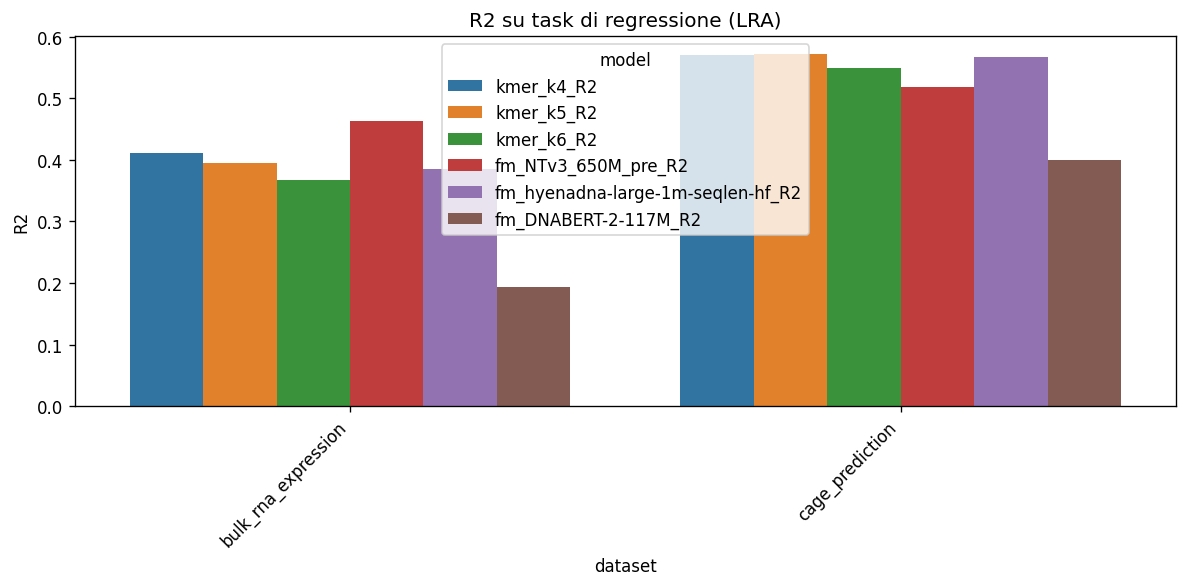

In [42]:
# LRA regression tasks
lra = pd.read_csv(LRA)

# righe con R2 disponibili
reg = lra[lra['kmer_k4_R2'].notna()].copy()

# seleziona modelli e prepara long format
r2_cols = [c for c in reg.columns if c.endswith('_R2')]
reg_long = reg.melt(id_vars=['dataset'], value_vars=r2_cols, var_name='model', value_name='R2')
reg_long['R2'] = pd.to_numeric(reg_long['R2'], errors='coerce')
reg_long = reg_long.dropna()

plt.figure(figsize=(10, 5))
sns.barplot(data=reg_long, x='dataset', y='R2', hue='model')
plt.xticks(rotation=45, ha='right')
plt.title('R2 su task di regressione (LRA)')
plt.tight_layout()
